In [56]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
 
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [57]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

TFIDF_VECTORIZER_PATH = MODELS_DIR / "tfidf_vectorizer.pkl"

LR_RESULTS_PATH = RESULTS_DIR / "logistic_regression_results.csv"

COMPARISON_ALL_METRICS_PATH = RESULTS_DIR / "comparison_all_metrics.csv"
MODEL_COMPARISON_PATH = RESULTS_DIR / "model_comparison_results.csv"
MODEL_COMPARISON_FIGURE_PATH = FIGURES_DIR / "model_comparison_macro_f1.png"

print("Project root:", PROJECT_ROOT)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)
print("TF-IDF vectorizer path:", TFIDF_VECTORIZER_PATH)

Project root: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project
Train path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\train.csv
Test path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\test.csv
TF-IDF vectorizer path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\tfidf_vectorizer.pkl


In [58]:
train_df = pd.read_csv(TRAIN_PATH, encoding="utf-8-sig")
test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (1972, 6)
Test shape: (494, 6)


,comment,chat_luong,dong_goi,van_chuyen,gia_ca,clean_comment
0,mỏng rộng,negative,neutral,neutral,neutral,mỏng rộng
1,nhỏ gọn chắc chắn. đóng gói cẩn thận,negative,positive,neutral,neutral,nhỏ gọn chắc chắn đóng gói cẩn thận
2,tập to bị móp góc,negative,negative,neutral,neutral,tập to bị móp góc
3,đóng gói sơ sài vận chuyển cong nhẹ,negative,negative,negative,neutral,đóng gói sơ sài vận chuyển cong nhẹ
4,sơ sài khác ảnh bị móp không vừa,negative,neutral,neutral,neutral,sơ sài khác ảnh bị móp không vừa


In [59]:
print(train_df.columns.tolist())
print(test_df.columns.tolist())

['comment', 'chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca', 'clean_comment']
['comment', 'chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca', 'clean_comment']


In [60]:
TEXT_COLUMN = "clean_comment"

aspect_columns = [
    "chat_luong",
    "dong_goi",
    "van_chuyen",
    "gia_ca"
]

label_order = ["positive", "negative", "neutral"]

X_train = train_df[TEXT_COLUMN].fillna("")
X_test = test_df[TEXT_COLUMN].fillna("")

y_train = train_df[aspect_columns]
y_test = test_df[aspect_columns]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1972,)
X_test shape: (494,)
y_train shape: (1972, 4)
y_test shape: (494, 4)


In [61]:
vectorizer = joblib.load(TFIDF_VECTORIZER_PATH)

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (1972, 3084)
X_test_tfidf shape: (494, 3084)


In [62]:
def evaluate_single_aspect(y_true, y_pred, aspect_name, model_name):
    """
    Evaluate one model on one aspect.
    """

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result = {
        "model": model_name,
        "aspect": aspect_name,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

    return result

In [63]:
def train_and_evaluate_model(
    model,
    model_name,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    aspect_columns,
    models_dir
):
    """
    Train and evaluate one classifier type for all aspects.

    Example:
    - model = MultinomialNB()
    - model_name = "Multinomial Naive Bayes"

    The function trains 4 separate models, one for each aspect.
    """

    all_results = {}
    all_predictions = {}

    for aspect in aspect_columns:
        print(f"Training {model_name} for aspect: {aspect}")

        # Create a fresh model object for each aspect
        current_model = model.__class__(**model.get_params())

        current_model.fit(X_train_tfidf, y_train[aspect])

        y_pred = current_model.predict(X_test_tfidf)

        result = evaluate_single_aspect(
            y_true=y_test[aspect],
            y_pred=y_pred,
            aspect_name=aspect,
            model_name=model_name
        )

        all_results[aspect] = result
        all_predictions[aspect] = y_pred

        safe_model_name = (
            model_name.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        model_path = models_dir / f"{safe_model_name}_{aspect}.pkl"
        joblib.dump(current_model, model_path)

        print(f"Saved model to: {model_path}")
        print(f"Macro F1: {result['macro_f1']:.4f}")
        print("-" * 80)

    return all_results, all_predictions

Training Multinomial Naive Bayes

In [64]:
nb_model = MultinomialNB()

nb_results, nb_predictions = train_and_evaluate_model(
    model=nb_model,
    model_name="Multinomial Naive Bayes",
    X_train_tfidf=X_train_tfidf,
    X_test_tfidf=X_test_tfidf,
    y_train=y_train,
    y_test=y_test,
    aspect_columns=aspect_columns,
    models_dir=MODELS_DIR
)

Training Multinomial Naive Bayes for aspect: chat_luong
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\multinomial_naive_bayes_chat_luong.pkl
Macro F1: 0.7031
--------------------------------------------------------------------------------
Training Multinomial Naive Bayes for aspect: dong_goi
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\multinomial_naive_bayes_dong_goi.pkl
Macro F1: 0.7230
--------------------------------------------------------------------------------
Training Multinomial Naive Bayes for aspect: van_chuyen
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\multinomial_naive_bayes_van_chuyen.pkl
Macro F1: 0.5882
--------------------------------------------------------------------------------
Training Multinomial Naive Bayes for aspect: gia_ca
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\multinomial_naive_bayes_gia_ca.pkl
Macro F1: 0.49

Training Linear SVM

In [65]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm_results, svm_predictions = train_and_evaluate_model(
    model=svm_model,
    model_name="Linear SVM",
    X_train_tfidf=X_train_tfidf,
    X_test_tfidf=X_test_tfidf,
    y_train=y_train,
    y_test=y_test,
    aspect_columns=aspect_columns,
    models_dir=MODELS_DIR
)

Training Linear SVM for aspect: chat_luong
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\linear_svm_chat_luong.pkl
Macro F1: 0.8057
--------------------------------------------------------------------------------
Training Linear SVM for aspect: dong_goi
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\linear_svm_dong_goi.pkl
Macro F1: 0.8770
--------------------------------------------------------------------------------
Training Linear SVM for aspect: van_chuyen
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\linear_svm_van_chuyen.pkl
Macro F1: 0.8243
--------------------------------------------------------------------------------
Training Linear SVM for aspect: gia_ca
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\linear_svm_gia_ca.pkl
Macro F1: 0.7732
--------------------------------------------------------------------------------


Training Random Forest

In [66]:
RUN_RANDOM_FOREST = True

rf_results = {}
rf_predictions = {}

if RUN_RANDOM_FOREST:
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_results, rf_predictions = train_and_evaluate_model(
        model=rf_model,
        model_name="Random Forest",
        X_train_tfidf=X_train_tfidf,
        X_test_tfidf=X_test_tfidf,
        y_train=y_train,
        y_test=y_test,
        aspect_columns=aspect_columns,
        models_dir=MODELS_DIR
    )
else:
    print("Random Forest is skipped because it is optional and may be slow for high-dimensional TF-IDF data.")

Training Random Forest for aspect: chat_luong
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\random_forest_chat_luong.pkl
Macro F1: 0.7542
--------------------------------------------------------------------------------
Training Random Forest for aspect: dong_goi
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\random_forest_dong_goi.pkl
Macro F1: 0.7911
--------------------------------------------------------------------------------
Training Random Forest for aspect: van_chuyen
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\random_forest_van_chuyen.pkl
Macro F1: 0.7187
--------------------------------------------------------------------------------
Training Random Forest for aspect: gia_ca
Saved model to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\models\random_forest_gia_ca.pkl
Macro F1: 0.7707
-----------------------------------------------------------------------------

In [67]:
lr_results_df = pd.read_csv(LR_RESULTS_PATH, encoding="utf-8-sig")

lr_results_df

,model,aspect,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Logistic Regression,chat_luong,0.8725,0.7619,0.8080,0.7813,0.8802,0.8725,0.8754
1,Logistic Regression,dong_goi,0.8846,0.8546,0.8350,0.8435,0.8860,0.8846,0.8847
2,Logistic Regression,van_chuyen,0.9575,0.7616,0.9311,0.8058,0.9748,0.9575,0.9640
3,Logistic Regression,gia_ca,0.9555,0.7667,0.7447,0.7552,0.9540,0.9555,0.9546


In [68]:
lr_results_df[["model", "aspect", "macro_f1", "weighted_f1"]]

,model,aspect,macro_f1,weighted_f1
0,Logistic Regression,chat_luong,0.7813,0.8754
1,Logistic Regression,dong_goi,0.8435,0.8847
2,Logistic Regression,van_chuyen,0.8058,0.9640
3,Logistic Regression,gia_ca,0.7552,0.9546


In [69]:
comparison_rows = []

# Logistic Regression results from Phase 7
for _, row in lr_results_df.iterrows():
    comparison_rows.append({
        "model": row["model"],
        "aspect": row["aspect"],
        "accuracy": row["accuracy"],
        "macro_precision": row["macro_precision"],
        "macro_recall": row["macro_recall"],
        "macro_f1": row["macro_f1"],
        "weighted_precision": row["weighted_precision"],
        "weighted_recall": row["weighted_recall"],
        "weighted_f1": row["weighted_f1"]
    })

# Naive Bayes
for aspect, result in nb_results.items():
    comparison_rows.append(result)

# Linear SVM
for aspect, result in svm_results.items():
    comparison_rows.append(result)

# Random Forest optional
if RUN_RANDOM_FOREST:
    for aspect, result in rf_results.items():
        comparison_rows.append(result)

comparison_all_metrics = pd.DataFrame(comparison_rows)

metric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1"
]

comparison_all_metrics[metric_columns] = comparison_all_metrics[metric_columns].round(4)

comparison_all_metrics

,model,aspect,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Logistic Regression,chat_luong,0.8725,0.7619,0.8080,0.7813,0.8802,0.8725,0.8754
1,Logistic Regression,dong_goi,0.8846,0.8546,0.8350,0.8435,0.8860,0.8846,0.8847
2,Logistic Regression,van_chuyen,0.9575,0.7616,0.9311,0.8058,0.9748,0.9575,0.9640
3,Logistic Regression,gia_ca,0.9555,0.7667,0.7447,0.7552,0.9540,0.9555,0.9546
4,Multinomial Naive Bayes,chat_luong,0.8806,0.9154,0.6740,0.7031,0.8860,0.8806,0.8685
5,Multinomial Naive Bayes,dong_goi,0.8279,0.9067,0.6566,0.7230,0.8522,0.8279,0.8061
6,Multinomial Naive Bayes,van_chuyen,0.9170,0.6101,0.5731,0.5882,0.9019,0.9170,0.9068
7,Multinomial Naive Bayes,gia_ca,0.8887,0.6274,0.4601,0.4961,0.8795,0.8887,0.8610
8,Linear SVM,chat_luong,0.9049,0.8207,0.7935,0.8057,0.9026,0.9049,0.9035
9,Linear SVM,dong_goi,0.9130,0.9100,0.8501,0.8770,0.9123,0.9130,0.9107


In [70]:
comparison_all_metrics.to_csv(
    COMPARISON_ALL_METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved all comparison metrics to:", COMPARISON_ALL_METRICS_PATH)

Saved all comparison metrics to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\comparison_all_metrics.csv


In [71]:
macro_f1_pivot = comparison_all_metrics.pivot_table(
    index="model",
    columns="aspect",
    values="macro_f1"
).reset_index()

macro_f1_pivot

aspect,model,chat_luong,dong_goi,gia_ca,van_chuyen
0,Linear SVM,0.8057,0.8770,0.7732,0.8243
1,Logistic Regression,0.7813,0.8435,0.7552,0.8058
2,Multinomial Naive Bayes,0.7031,0.7230,0.4961,0.5882
3,Random Forest,0.7542,0.7911,0.7707,0.7187


In [72]:
model_comparison_results = macro_f1_pivot.rename(columns={
    "chat_luong": "chat_luong_macro_f1",
    "dong_goi": "dong_goi_macro_f1",
    "van_chuyen": "van_chuyen_macro_f1",
    "gia_ca": "gia_ca_macro_f1"
})

macro_f1_columns = [
    "chat_luong_macro_f1",
    "dong_goi_macro_f1",
    "van_chuyen_macro_f1",
    "gia_ca_macro_f1"
]

model_comparison_results["average_macro_f1"] = model_comparison_results[macro_f1_columns].mean(axis=1)

model_comparison_results[macro_f1_columns + ["average_macro_f1"]] = (
    model_comparison_results[macro_f1_columns + ["average_macro_f1"]].round(4)
)

model_comparison_results = model_comparison_results.sort_values(
    by="average_macro_f1",
    ascending=False
)

model_comparison_results

aspect,model,chat_luong_macro_f1,dong_goi_macro_f1,gia_ca_macro_f1,van_chuyen_macro_f1,average_macro_f1
0,Linear SVM,0.8057,0.8770,0.7732,0.8243,0.8200
1,Logistic Regression,0.7813,0.8435,0.7552,0.8058,0.7964
3,Random Forest,0.7542,0.7911,0.7707,0.7187,0.7587
2,Multinomial Naive Bayes,0.7031,0.7230,0.4961,0.5882,0.6276


In [73]:
model_comparison_results.to_csv(
    MODEL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved model comparison results to:", MODEL_COMPARISON_PATH)

Saved model comparison results to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\model_comparison_results.csv


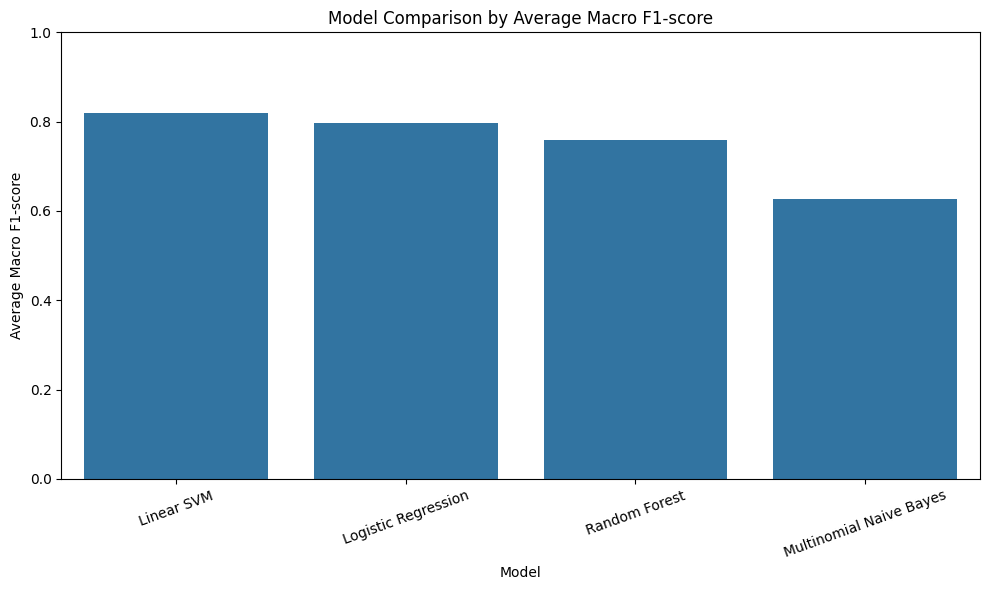

Saved figure to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\report\figures\model_comparison_macro_f1.png


In [76]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison_results,
    x="model",
    y="average_macro_f1"
)

plt.title("Model Comparison by Average Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Average Macro F1-score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(MODEL_COMPARISON_FIGURE_PATH, dpi=300)
plt.show()

print("Saved figure to:", MODEL_COMPARISON_FIGURE_PATH)

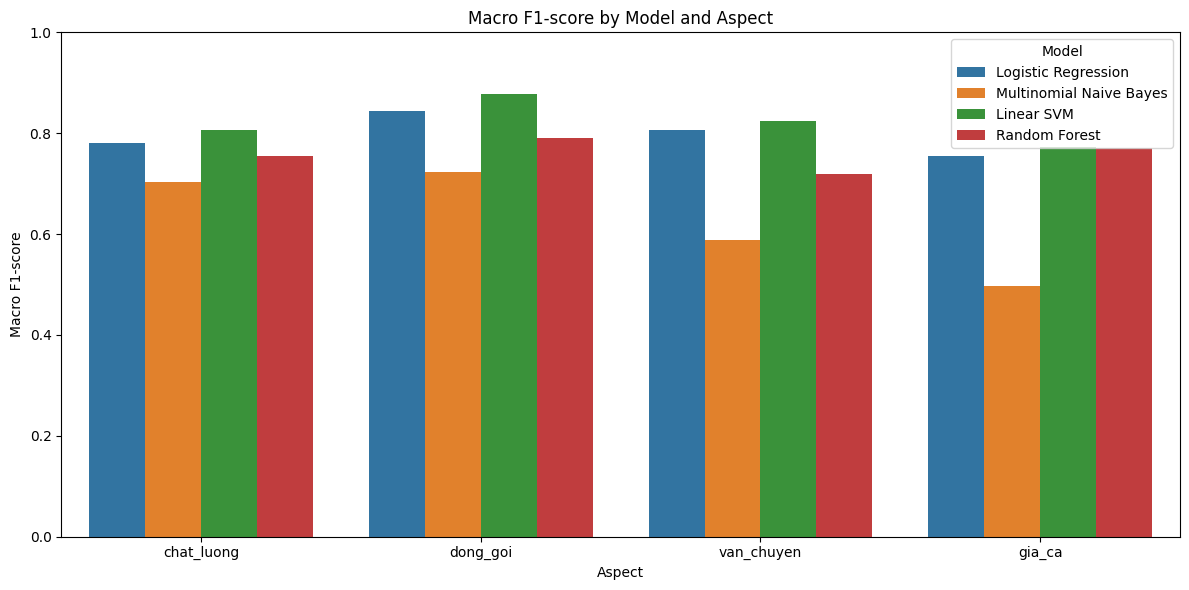

Saved figure to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\report\figures\model_comparison_macro_f1_by_aspect.png


In [77]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_all_metrics,
    x="aspect",
    y="macro_f1",
    hue="model"
)

plt.title("Macro F1-score by Model and Aspect")
plt.xlabel("Aspect")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()

aspect_comparison_figure_path = FIGURES_DIR / "model_comparison_macro_f1_by_aspect.png"
plt.savefig(aspect_comparison_figure_path, dpi=300)
plt.show()

print("Saved figure to:", aspect_comparison_figure_path)